# Week 10 of learning python with TDI (The Data Immersed)


In [1]:
#week 10: Advanced Visualization with Seaborn

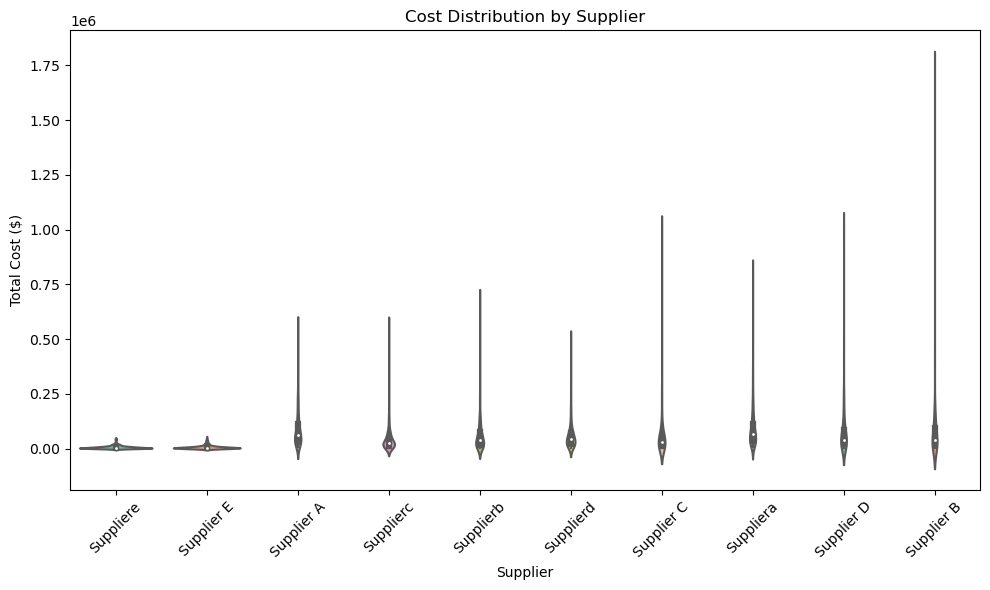

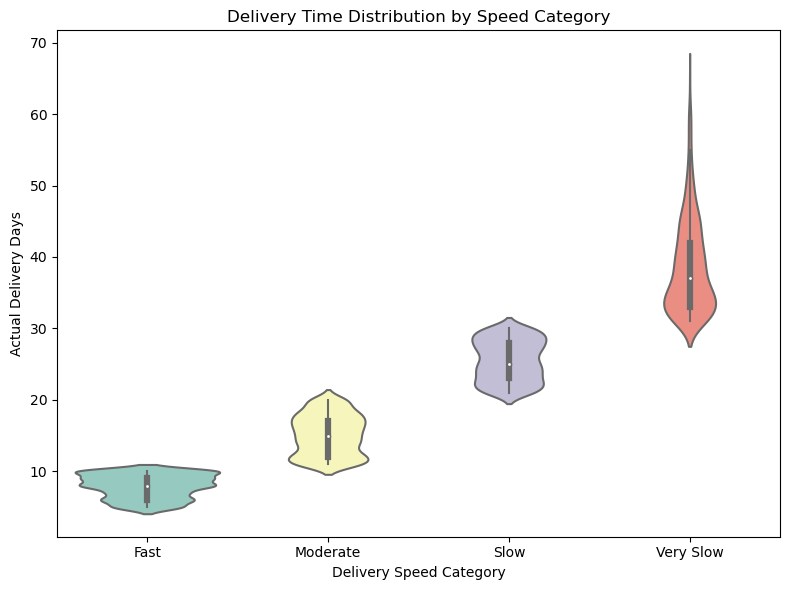

In [4]:
#Task 1: Create Violin Plots Comparing Distributions by Group 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# Create a delivery speed category based on actual_delivery_days
df["delivery_speed_category"] = pd.cut(
    df["actual_delivery_days"],
    bins=[0, 10, 20, 30, df["actual_delivery_days"].max()],
    labels=["Fast", "Moderate", "Slow", "Very Slow"]
)

# --- Violin Plot 1: Cost Distribution by Supplier ---
plt.figure(figsize=(10,6))
sns.violinplot(
    x="supplier_name", 
    y="total_cost", 
    data=df, 
    inner="box", 
    palette="Set2"
)
plt.title("Cost Distribution by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Total Cost ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("cost_by_supplier_violin.png", dpi=100)
plt.show()

# --- Violin Plot 2: Delivery Speed vs Days to Deliver ---
plt.figure(figsize=(8,6))
sns.violinplot(
    x="delivery_speed_category", 
    y="actual_delivery_days", 
    data=df, 
    inner="box", 
    palette="Set3"
)
plt.title("Delivery Time Distribution by Speed Category")
plt.xlabel("Delivery Speed Category")
plt.ylabel("Actual Delivery Days")
plt.tight_layout()
plt.savefig("delivery_speed_violin.png", dpi=100)
plt.show()



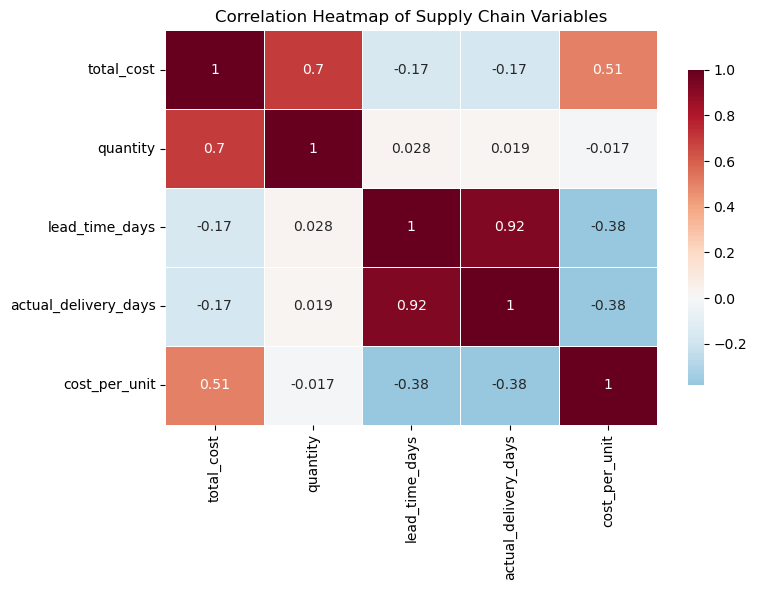

In [5]:
#Task 2: Create Heatmaps Showing Correlations 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# Create cost_per_unit column
df["cost_per_unit"] = df["total_cost"] / df["quantity"]

# Select numeric columns
numeric_cols = ["total_cost", "quantity", "lead_time_days", "actual_delivery_days", "cost_per_unit"]

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values
    cmap="RdBu_r",       # diverging palette (red=positive, blue=negative)
    center=0,            # white at zero
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Supply Chain Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100)
plt.show()


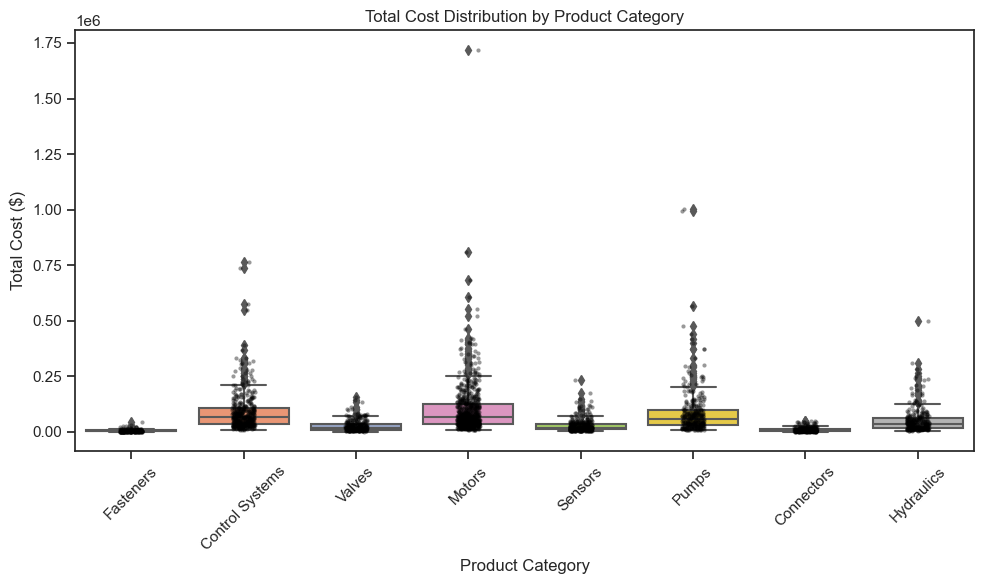

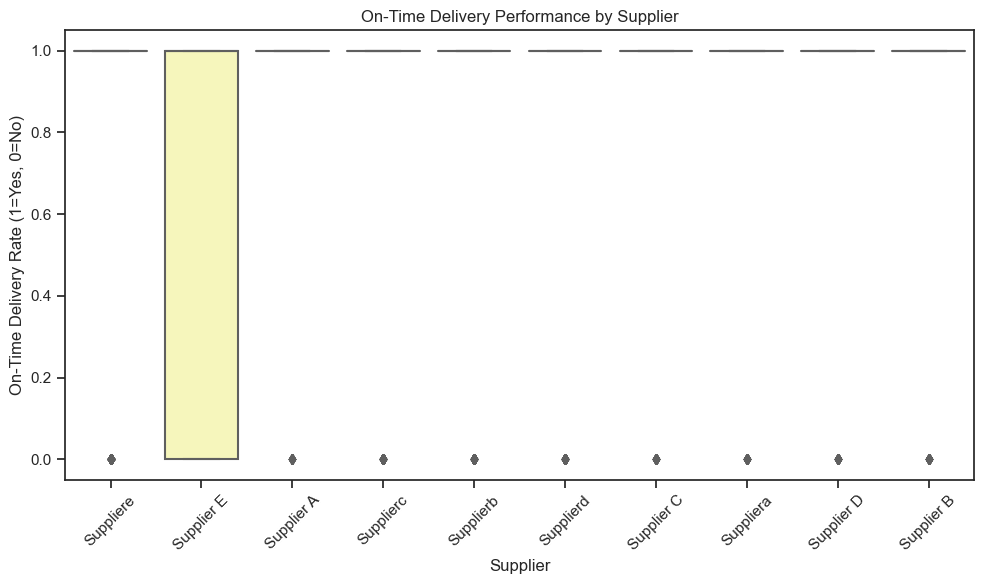

In [20]:
#Task3: Create Box Plots and Swarm Plots for Categorical Comparison 

#Create Chart 1: Box plot of total_cost by product_category
#Create Chart 2: Box plot of on_time by supplier_name

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Ignore placement warnings from Seaborn
warnings.filterwarnings("ignore", category=UserWarning)

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# --- Chart 1: Box plot + Strip plot of total_cost by product_category ---
plt.figure(figsize=(10,6))

# Use a style without grid lines
sns.set_theme(style="ticks", palette="Set2")

sns.boxplot(
    x="product_category", 
    y="total_cost", 
    data=df, 
    palette="Set2"
)
sns.stripplot(
    x="product_category", 
    y="total_cost", 
    data=df, 
    color="black", 
    alpha=0.4, 
    jitter=True, 
    size=3
)

plt.title("Total Cost Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Cost ($)")
plt.xticks(rotation=45)

# Remove grid lines
plt.grid(False)

plt.tight_layout()
plt.savefig("box_strip_cost_by_category.png", dpi=100)
plt.show()

# --- Chart 2: Box plot of on_time by supplier_name ---
df["on_time_numeric"] = df["on_time"].map({"Yes":1, "No":0})

plt.figure(figsize=(10,6))

sns.boxplot(
    x="supplier_name", 
    y="on_time_numeric", 
    data=df, 
    palette="Set3"
)

plt.title("On-Time Delivery Performance by Supplier")
plt.xlabel("Supplier")
plt.ylabel("On-Time Delivery Rate (1=Yes, 0=No)")
plt.xticks(rotation=45)

# Remove grid lines
plt.grid(False)

plt.tight_layout()
plt.savefig("box_on_time_by_supplier.png", dpi=100)
plt.show()




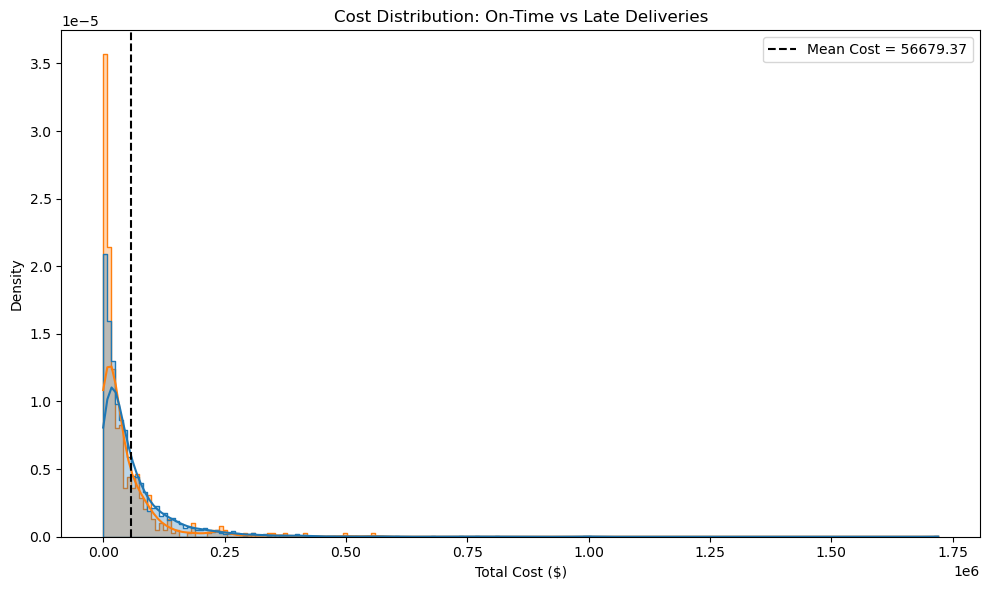

In [9]:
#Task 4: Create KDE Plots for Smooth Distributions 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# Convert on_time Yes/No to a clean categorical column
df["on_time_status"] = df["on_time"].map({"Yes":"On-Time", "No":"Late"})

# Calculate mean cost
mean_cost = df["total_cost"].mean()

# --- KDE + Histogram Plot ---
plt.figure(figsize=(10,6))
sns.histplot(
    data=df, 
    x="total_cost", 
    hue="on_time_status", 
    kde=True, 
    element="step", 
    stat="density", 
    common_norm=False, 
    alpha=0.3
)

# Add vertical line for mean
plt.axvline(mean_cost, color="black", linestyle="--", linewidth=1.5, label=f"Mean Cost = {mean_cost:.2f}")

plt.title("Cost Distribution: On-Time vs Late Deliveries")
plt.xlabel("Total Cost ($)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("cost_kde_by_status.png", dpi=100)
plt.show()


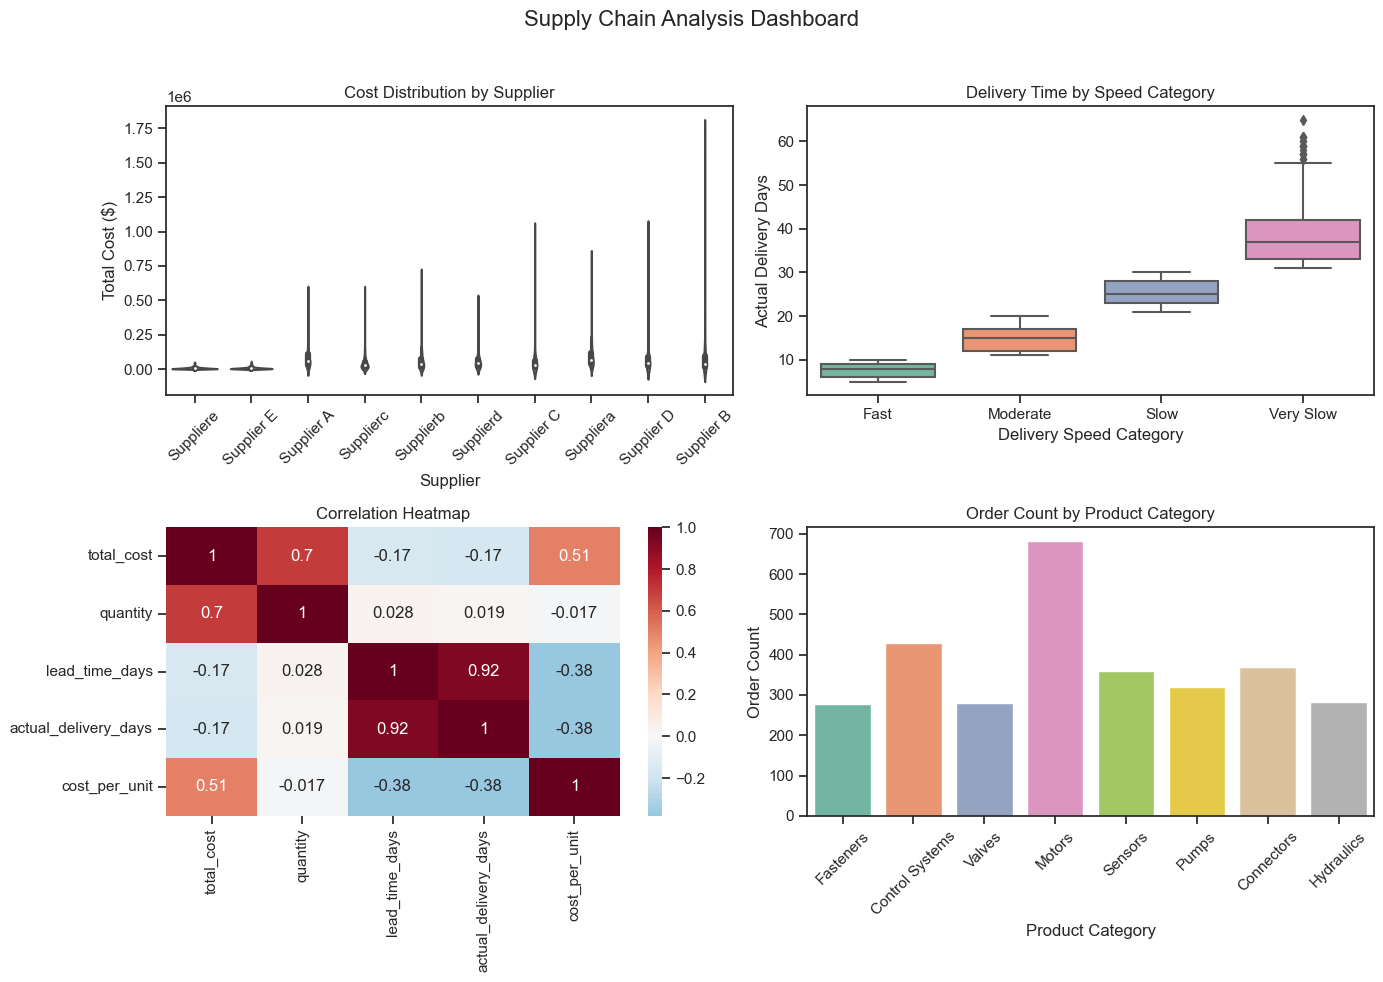

In [19]:
#Task5:Create a Comprehensive Multi-Panel Seaborn Dashboard 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# Create delivery_speed_category from actual_delivery_days
df["delivery_speed_category"] = pd.cut(
    df["actual_delivery_days"],
    bins=[0, 10, 20, 30, df["actual_delivery_days"].max()],
    labels=["Fast", "Moderate", "Slow", "Very Slow"]
)

# Create cost_per_unit column
df["cost_per_unit"] = df["total_cost"] / df["quantity"]

# Select numeric columns for correlation
numeric_cols = ["total_cost", "quantity", "lead_time_days", "actual_delivery_days", "cost_per_unit"]
corr_matrix = df[numeric_cols].corr()

# Set consistent style and palette WITHOUT grid lines
sns.set_theme(style="ticks", palette="Set2")

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Subplot 1: Violin plot of total_cost by supplier_name ---
sns.violinplot(
    x="supplier_name", 
    y="total_cost", 
    data=df, 
    inner="box", 
    ax=axes[0,0]
)
axes[0,0].set_title("Cost Distribution by Supplier")
axes[0,0].set_xlabel("Supplier")
axes[0,0].set_ylabel("Total Cost ($)")
axes[0,0].tick_params(axis='x', rotation=45)

# --- Subplot 2: Box plot of days_to_deliver by delivery_speed_category ---
sns.boxplot(
    x="delivery_speed_category", 
    y="actual_delivery_days", 
    data=df, 
    ax=axes[0,1]
)
axes[0,1].set_title("Delivery Time by Speed Category")
axes[0,1].set_xlabel("Delivery Speed Category")
axes[0,1].set_ylabel("Actual Delivery Days")

# --- Subplot 3: Heatmap of correlations ---
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="RdBu_r", 
    center=0, 
    ax=axes[1,0]
)
axes[1,0].set_title("Correlation Heatmap")

# --- Subplot 4: Count plot of product_category ---
sns.countplot(
    x="product_category", 
    data=df, 
    ax=axes[1,1]
)
axes[1,1].set_title("Order Count by Product Category")
axes[1,1].set_xlabel("Product Category")
axes[1,1].set_ylabel("Order Count")
axes[1,1].tick_params(axis='x', rotation=45)

# Remove grid lines from all subplots
for ax in axes.flat:
    ax.grid(False)

# Add overall title
fig.suptitle("Supply Chain Analysis Dashboard", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("seaborn_dashboard.png", dpi=120)
plt.show()




In [14]:
#Shifted from simple charts to sophisticated, publication‑quality visualizations.
#Created violin plots, box plots, strip/swarm plots, KDE distributions, and heatmaps to reveal deeper patterns.
#Learned how to customize palettes, themes, and styling for clarity and professionalism.
#Built a multi‑panel Seaborn dashboard combining multiple plots into one cohesive analysis.
#Excited to use advanced visualizations to uncover complex relationships and tell complete data stories!
